In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet_v2 import UnetV2, UnetV2NoTime



/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [3]:

%%capture
im_size = 128
problem = "ct-circles"
ckp_index = 37750
checkpoint_path = f'problems/{problem}/checkpoints/ckp_{ckp_index}.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# match the number of channels to your model
model = UnetV2(ch=32).to(device)

_, _, model, _, _, _= load_checkpoint(model=model, path=checkpoint_path)
model.eval()

/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [16]:
# load inverse nn
inv_model = UnetV2NoTime(ch=32).to(device)
ckp_index = 37750
checkpoint_path = f'problems/inverse-operator/{problem}-2-24/checkpoints/ckp_{ckp_index}.tar'
_, _, inv_model, _, _, _= load_checkpoint(model=inv_model, path=checkpoint_path)

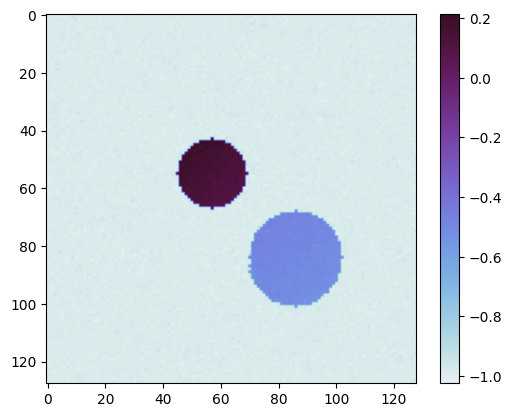

In [17]:
# test model out quickly
# with torch.autograd.profiler.profile(use_device='cuda') as prof:
img = sample_images(model, (1,1,im_size,im_size), num_steps=5, device=device)
# print(prof.key_averages().table(sort_by="cuda_time_total"))
img = img[-1].squeeze().cpu().numpy()
plt.imshow(img, cmap=cmocean.cm.dense)
plt.colorbar() # note that our flow model is normalized to [-1,1]

In [18]:
from typing import Callable, Dict, List, Optional

from torch import autocast
from torchdiffeq import odeint_adjoint 
import torch.nn as nn


def inverse_loss_fn(x, y, media, lambda_reg=1e-2):
    """
    Loss function with Tikhonov (L2) regularization.
    
    Args:
        x: predicted values
        y: target values  
        lambda_reg: regularization parameter
    """
    data_loss = torch.nn.functional.mse_loss(x, y) 
    
    # Tikhonov regularization term (L2 norm of x)
    reg_loss = lambda_reg * torch.norm(media, p=2)**2
    
    # Total loss
    total_loss = data_loss + reg_loss
    
    return total_loss

def ode_integrate(ode_func: nn.Module,
                  init_x: torch.Tensor,
                  ode_opts: Dict = {},
                  t_eps: float = 0,
                  init_t: float = 0.,
                  final_t: float = 1.,
                  t_arr: Optional[List[float]] = None,
                  num_steps: int = 5,
                  intermediate_points: bool = False
      ) -> torch.Tensor:

    if t_arr is None:
        t = torch.linspace(init_t - t_eps, final_t, num_steps).to(init_x.device)
    else:
        t = torch.tensor(t_arr, dtype=torch.float32, device=init_x.device)

    ode_opts = {
        "atol": 1e-5, 
        "rtol": 1e-5, 
        "method": "dopri5", # "dopri5", "rk4", "euler", "adams", "bdf"
        **ode_opts
    }

    z = odeint(
        func = lambda t, x: ode_func(x, t.expand(x.shape[0])),
        y0 = init_x,
        t = t,
        **ode_opts
    )

    if not intermediate_points:
        return z[-1]
    return z


In [19]:

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(num_params)


1729793


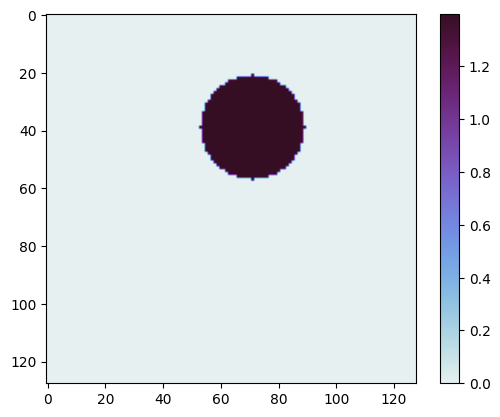

In [20]:
# load data and select a random ground truth from test set
import os
from transforms.radon import radon_transform
import cmocean as cmo
test_data = torch.load(f'data/{problem}-dataset-{im_size}.pt')["test"]
idx = np.random.randint(0, len(test_data))
gt = test_data[idx].to(device).unsqueeze(0)
plt.imshow(gt.squeeze().cpu(), cmap=cmo.cm.dense)
plt.colorbar()

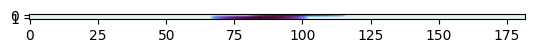

In [21]:
# load mesh
sparse_radon = radon_transform(gt, N=2)

plt.imshow(sparse_radon.squeeze(0).squeeze(0).cpu().detach().numpy(), cmap=cmo.cm.dense)


In [22]:
# getting normalization constants
train_min, train_max = torch.min(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"]), torch.max(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"])

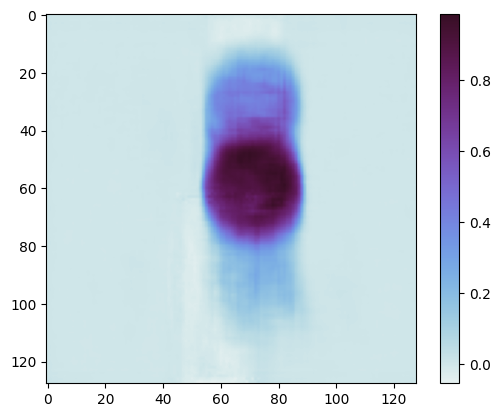

In [23]:
inverse_output = inv_model(sparse_radon.float())
plt.imshow(inverse_output.squeeze().cpu().detach().numpy(), cmap=cmo.cm.dense)
plt.colorbar()

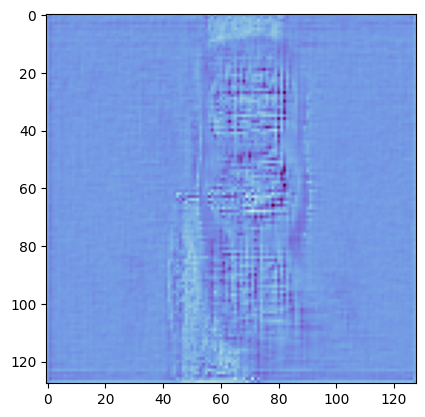

In [24]:
# solve the reverse ode given inverse output as initial condition
t = torch.linspace(1., 0., 10).to(device)
with torch.no_grad():
    inv_output_gaussian = odeint(
                    func = lambda t, x: model(x, t.expand(x.shape[0])),
                    t = t,
                    y0 = 2.0 * (inverse_output - train_min) / (train_max - train_min) - 1.0 ,
                    method = 'dopri5',
                    atol = 1e-5,
                    rtol = 1e-5,
                )[-1].squeeze().cpu()
plt.imshow(inv_output_gaussian, cmap=cmocean.cm.dense)


In [ ]:
max_iter = 20
optim_steps = 1000
target_cost = 1e-4
time_limit = 500
lr = 1e-3
x1_trajectory = []
dtn_trajectory = []
# init_x = torch.randn((1, 1, im_size, im_size), device=device, dtype=torch.float32)
init_x = inv_output_gaussian.unsqueeze(0).to(device)
init_x.requires_grad = True
y = sparse_radon # history_size depends on your VRAM.
# optimizer = optim.LBFGS([init_x], max_iter=max_iter, lr=lr, history_size=10)
# or we can try sgd
# optimizer = torch.optim.SGD([init_x], lr=lr, nesterov=False, momentum=0.0)
optimizer = optim.Adam([init_x], lr=lr, betas=(0.9, 0.99), eps=1e-8, weight_decay=0.01)

svd_traj = []

metrics = {'loss': CatMetric(), 
           'cost': CatMetric(), 
           'norm_x0': CatMetric(), 
           'std_x0': CatMetric(), 
           'mean_x0': CatMetric(), 
           'time': CatMetric()
           }
start_time = time.time()
# add metrics to tqdm
for step in range(optim_steps):
    def closure():
        global loss
        global x1
        global dtn_trajectory
        optimizer.zero_grad()

        ### solve for x1
        x1 = ode_integrate(ode_func=model, init_x =init_x, num_steps=5)
        # unnormalize x1
        x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
        
        # degraded_x1 = H(x1)
        degraded_x1 = radon_transform(x1, N=1)
        dtn_trajectory.append(degraded_x1.detach().cpu().numpy())

        cost = inverse_loss_fn(degraded_x1, y, x1,lambda_reg=0)
        loss = cost 

        norm_x0 = init_x.norm()
        std_x0 = init_x.std()
        mean_x0 = init_x.mean()

        metrics['norm_x0'].update(norm_x0.item())
        metrics['std_x0'].update(std_x0.item())
        metrics['mean_x0'].update(mean_x0.item())
        metrics['cost'].update(cost.item())
        metrics['loss'].update(loss.item())

        loss.backward()
        return loss


    optimizer.step(closure)
    


    x1_trajectory.append(x1.detach().cpu().numpy())

     # print metrics


    elapsed = time.time() - start_time
    metrics['time'].update(elapsed)

    elapsed = elapsed/60
    print(f"[Step {step}] Loss {loss.item()}"
        + f"| time: {elapsed} mins")

    if target_cost is not None:
        mets_cost = metrics['cost'].compute()
        if mets_cost.dim() > 0:
            mets_cost = mets_cost[-1]
        last_cost = mets_cost.item()
        if last_cost <= target_cost:
            print(f'reached cost of {last_cost}')
            break

    if time_limit is not None:
        elapsed = (time.time() - start_time)/60 # time in minutes
        if elapsed > time_limit:
            print(f'reached time limit of {time_limit} mins')
            break

with torch.no_grad():
    x1 = ode_integrate(model, init_x)
    x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
x1_trajectory.append(x1.detach().cpu().numpy())



/tmp/ipykernel_3826558/2865289285.py:17: UserWarning: Using a target size (torch.Size([1, 1, 2, 182])) that is different to the input size (torch.Size([1, 1, 1, 182])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  data_loss = torch.nn.functional.mse_loss(x, y)


[Step 0] Loss 143.44415283203125| time: 0.027812318007151286 mins
[Step 1] Loss 208.0765838623047| time: 0.05488929351170858 mins
[Step 2] Loss 220.67613220214844| time: 0.08592048088709513 mins
[Step 3] Loss 224.41754150390625| time: 0.11695400873819987 mins
[Step 4] Loss 223.4952392578125| time: 0.15158937374750772 mins
[Step 5] Loss 214.27151489257812| time: 0.17971802552541097 mins


KeyboardInterrupt: 

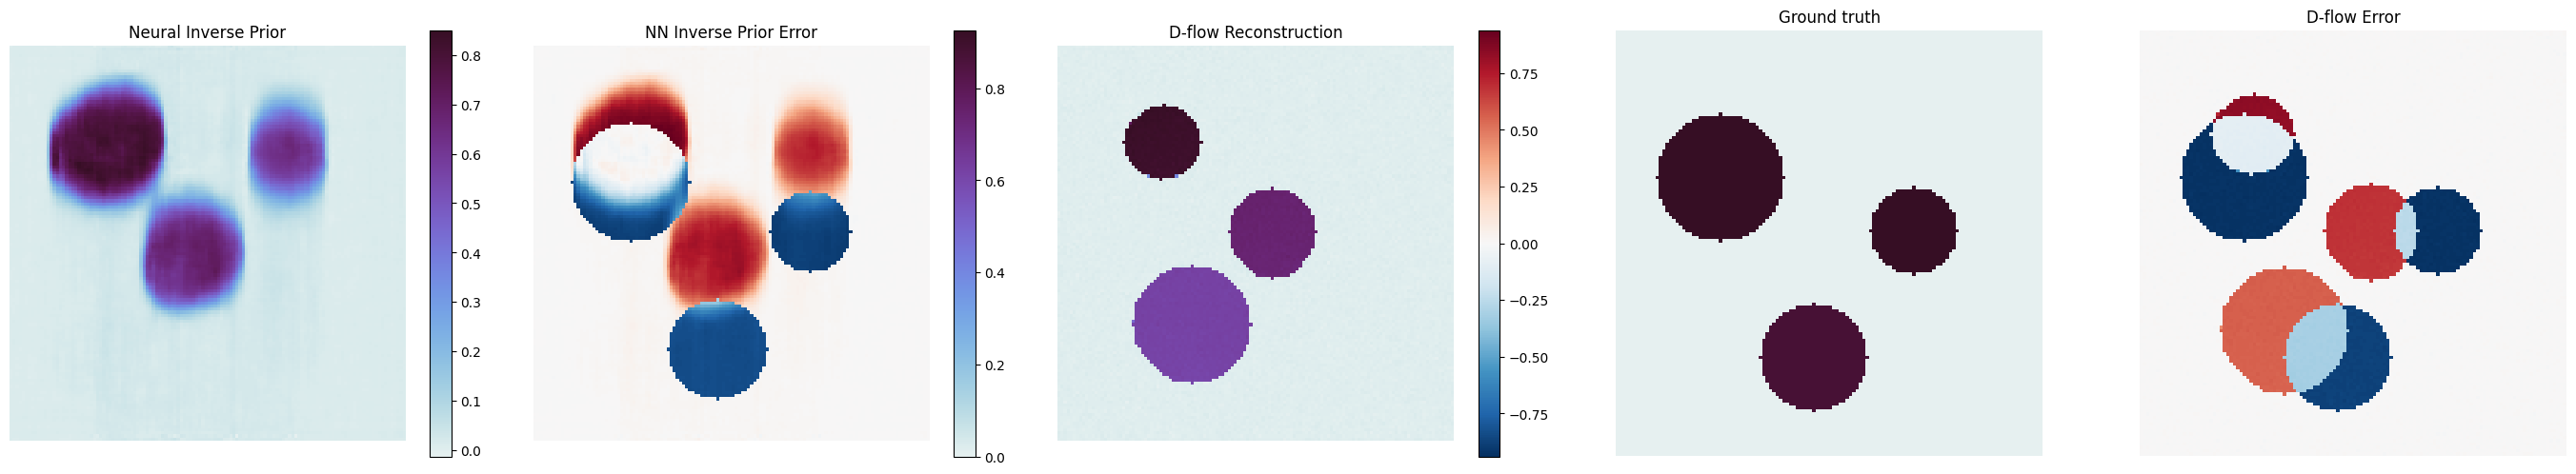

Neural network results
MSE: 0.133616
MAE: 0.186911
PSNR: 11.66 dB
Rel. L2 Error: 1.0382
D-flow Results
MSE: 0.122697
MAE: 0.160581
PSNR: 12.03 dB
Rel. L2 Error: 0.9949


In [14]:
import warnings

# Suppress warnings from transforms
warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(divide='ignore', invalid='ignore')

# plot error and final result
fig, axes = plt.subplots(1, 5, figsize=(27.5, 5))

# neural inverse prior
im0 = axes[0].imshow(inverse_output.squeeze().cpu().detach().numpy(), cmap=cmocean.cm.dense)
axes[0].set_title('Neural Inverse Prior')
axes[0].axis('off')

# error of nn reconstruction 
error = inverse_output.squeeze().cpu().detach().numpy() - gt.squeeze().cpu().numpy()
im1 = axes[1].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[1].set_title('NN Inverse Prior Error')
axes[1].axis('off')

# Reconstructed image (D-flow)
im1 = axes[2].imshow(x1.squeeze().detach().cpu().numpy(), cmap=cmocean.cm.dense)
axes[2].set_title('D-flow Reconstruction')
axes[2].axis('off')
plt.colorbar(im1, ax=axes[0])


# Original image
im3 = axes[3].imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
axes[3].set_title('Ground truth')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[1])

# Error/difference (D-flow vs Original)
error = x1.squeeze().detach().cpu().numpy() - gt.squeeze().cpu().numpy()
im4 = axes[4].imshow(error, cmap='RdBu_r', vmin=-np.abs(error).max(), vmax=np.abs(error).max())
axes[4].set_title('D-flow Error')
axes[4].axis('off')
plt.colorbar(im4, ax=axes[2])

plt.tight_layout()
plt.show()

max_pix = test_data.max() - test_data.min()
max_pix = max_pix.item()
# Print comparison metrics
mse_dflow = np.mean(error**2)
mae_dflow = np.mean(np.abs(error))
psnr_dflow = 20 * np.log10(max_pix / np.sqrt(mse_dflow))

print("Neural network results")
mse_nn = np.mean((inverse_output.squeeze().cpu().detach().numpy() - gt.squeeze().cpu().numpy())**2)
mae_nn = np.mean(np.abs(inverse_output.squeeze().cpu().detach().numpy() - gt.squeeze().cpu().numpy()))
psnr_nn = 20 * np.log10(max_pix / np.sqrt(mse_nn))
print(f"MSE: {mse_nn:.6f}")
print(f"MAE: {mae_nn:.6f}")
print(f"PSNR: {psnr_nn:.2f} dB")
print(f"Rel. L2 Error: {np.linalg.norm(inverse_output.squeeze().cpu().detach().numpy() - gt.squeeze().cpu().numpy()) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}")

print("D-flow Results")
print(f"MSE: {mse_dflow:.6f}")
print(f"MAE: {mae_dflow:.6f}")
print(f"PSNR: {psnr_dflow:.2f} dB")
print(f"Rel. L2 Error: {np.linalg.norm(error) / np.linalg.norm(gt.squeeze().cpu().numpy()):.4f}")


In [15]:
import matplotlib.animation as animation
from IPython.display import HTML

# Create animation of x1 trajectory
fig, ax = plt.subplots(figsize=(8, 8))

def animate(frame):
    ax.clear()
    img = x1_trajectory[frame].squeeze()
    im = ax.imshow(img, cmap=cmocean.cm.dense, vmin=img.min(), vmax=img.max())
    ax.set_title(f'D-flow Reconstruction - Step {frame}', fontsize=14)
    ax.axis('off')
    return [im]

frame_indices = list(range(len(x1_trajectory)))
if len(frame_indices) > 100:  # Limit to 100 frames max
    frame_indices = frame_indices[::len(frame_indices)//100]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=frame_indices, 
                             interval=200, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_anim = HTML(anim.to_jshtml())
html_anim

In [77]:
# Create side-by-side comparison animation
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

gt_img = gt.squeeze().cpu().numpy()

def animate_comparison(frame):
    # Clear all axes
    ax1.clear()
    ax2.clear() 
    ax3.clear()
    
    # Current reconstruction
    current_img = x1_trajectory[frame].squeeze()
    
    # Plot reconstruction
    im1 = ax1.imshow(current_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax1.set_title(f'Reconstruction - Step {frame}', fontsize=12)
    ax1.axis('off')
    
    # Plot ground truth
    im2 = ax2.imshow(gt_img, cmap=cmocean.cm.dense, vmin=gt_img.min(), vmax=gt_img.max())
    ax2.set_title('Ground Truth', fontsize=12)
    ax2.axis('off')
    
    # Plot difference
    diff = current_img - gt_img
    im3 = ax3.imshow(diff, cmap='RdBu_r', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
    ax3.set_title(f'Difference', fontsize=12)
    
    # report MAE and MSE over time
    mae = np.mean(np.abs(diff))
    mse = np.mean(diff**2)
    psnr = 20 * np.log10(max_pix / np.sqrt(mse))
    rel_l2 = np.linalg.norm(diff) / np.linalg.norm(gt_img)

    # place on caption of fig
    fig.suptitle(f'MAE: {mae:.4f}, MSE: {mse:.4f}, PSNR: {psnr:.2f} dB, Rel. L2: {rel_l2:.4f}', fontsize=12)
    # turn off ticks
    ax3.axis('off')

    
    return [im1, im2, im3]

# Use same frame sampling as before
anim_comparison = animation.FuncAnimation(fig, animate_comparison, frames=frame_indices, 
                                        interval=300, blit=False, repeat=True)

plt.close(fig)  # Close the figure to prevent blank canvas display

# Convert to HTML5 video for inline playback
html_comparison = HTML(anim_comparison.to_jshtml())
html_comparison